In [7]:
from yong import *
from pandas import CategoricalDtype
import numpy as np
from sklearn.impute import SimpleImputer
from pandas import DataFrame
from yong import load_data
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

In [8]:
origin = load_data('traffic_acc')
origin

2005년 1월 부터 2018년 12월 까지 월별 교통사고의 발생건수,부상자수,사망자수 데이터(인덱스/메타데이터 없음, 출처: 공공데이터포털)


,년도,월,발생건수,사망자수,부상자수
0,2005,1,15494,504,25413
1,2005,2,13244,431,21635
2,2005,3,16580,477,25550
3,2005,4,17817,507,28131
4,2005,5,19085,571,29808
...,...,...,...,...,...
163,2018,8,18335,357,27749
164,2018,9,18371,348,27751
165,2018,10,19738,373,28836
166,2018,11,19029,298,28000


In [9]:
df1 = origin.drop('월', axis = 1).groupby('년도').mean()
df1

,발생건수,사망자수,부상자수
년도,,,
2005,17847.583,531.333,28519.417
2006,17812.083,527.250,28352.417
2007,17638.500,513.833,27992.167
2008,17985.167,489.167,28246.833
2009,19332.500,486.500,30156.250
2010,18906.500,458.750,29371.500
2011,18475.917,435.750,28449.250
2012,18638.000,449.333,28713.750
2013,17946.167,424.333,27392.583


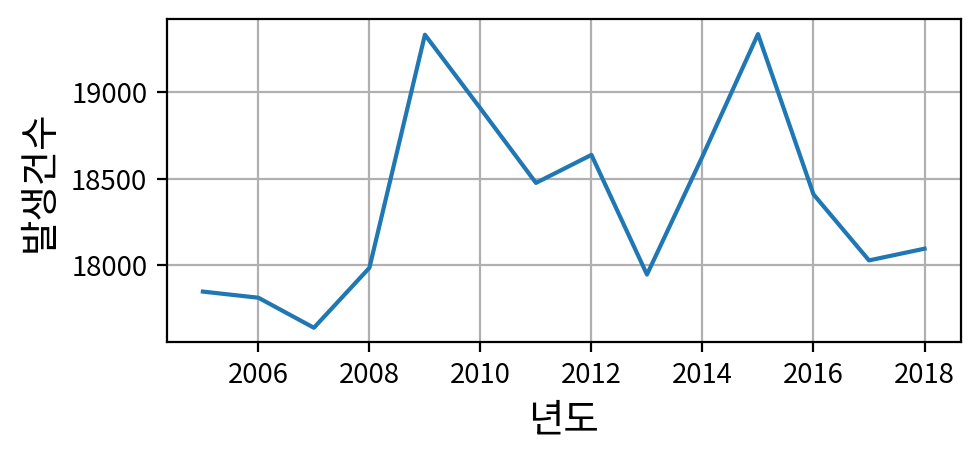

In [10]:
width_px = 1000
height_px = 480
rows = 1
cols = 1
figsize = (width_px/ my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize = figsize, dpi = my_dpi)

# 그래프 그리기, seaborn 사용
sb.lineplot(data = df1, x= '년도', y = '발생건수',
         )


# 출력
plt.grid()
plt.tight_layout()
plt.show()
plt.close()

In [11]:
origin = load_data('covid19_active')
display(origin)
display(origin.info())

2022년 5월 1일부터 2023년 5월 31일까지 서울과 전국의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)


,서울시 일일 확진,전국 일일 확진
기준일,,
2023-05-31,5987.000,24411.000
2023-05-30,3326.000,13529.000
2023-05-29,1393.000,6868.000
2023-05-28,1393.000,6868.000
2023-05-27,4078.000,17796.000
...,...,...
2022-05-05,6645.000,42296.000
2022-05-04,7436.000,49064.000
2022-05-03,8709.000,51131.000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 396 entries, 2023-05-31 to 2022-05-01
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   서울시 일일 확진  395 non-null    float64
 1   전국 일일 확진   395 non-null    float64
dtypes: float64(2)
memory usage: 9.3 KB


None

In [18]:
# X좌표(인덱스) 직접 생성
x_index = origin.index.sort_values()
xx = list(range(0, len(x_index), 30))
xx

[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390]

In [19]:
xticks = []

for i in xx:
    xticks.append(x_index[i].strftime('%y/%m/%d'))

xticks

['22/05/01',
 '22/05/31',
 '22/06/30',
 '22/07/30',
 '22/08/29',
 '22/09/28',
 '22/10/28',
 '22/11/27',
 '22/12/27',
 '23/01/26',
 '23/02/25',
 '23/03/27',
 '23/04/26',
 '23/05/26']

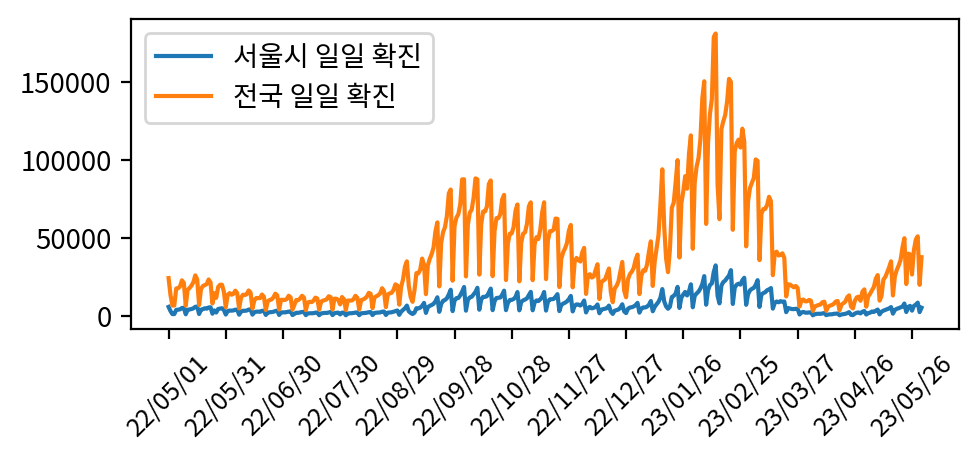

In [24]:
width_px = 1000
height_px = 480
cols = 1
figsize = (width_px/ my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize = figsize, dpi = my_dpi)

# 그래프 그리기, seaborn 사용
sb.lineplot(data = origin['서울시 일일 확진'].values, label = '서울시 일일 확진' 
            )
sb.lineplot(data = origin['전국 일일 확진'].values, label = '전국 일일 확진'
            )

# 그래프 꾸미기
ax.grid(True) # 배경 격자 표시/숨김

ax.set_xticks(xx, xticks, rotation = 45, fontsize = 9)
#ax.set_xlabel('서울시 일일 확진')
#ax.set_ylabel('전국 일일 확진')
# 출력
plt.grid()
plt.tight_layout()
plt.show()
plt.close()